## Setup

In [1]:
import sys, json, os, time, re
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from itertools import product
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import seaborn as sns
from tqdm import tqdm
import random
import zlib
import importlib
from cycler import cycler
from scipy.stats import norm

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER")
SRC_DIR = str(Path(PROJECT_DIR) / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import multiomic_transformer.utils.experiment_loader as experiment_loader
from multiomic_transformer.models.model_simplified import MultiomicTransformer
from multiomic_transformer.datasets.dataset_refactor import (
    SimpleScaler,
)

GROUND_TRUTH_DIR = PROJECT_DIR / "data" / "ground_truth_files"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
TRAINING_CACHE_DIR = PROJECT_DIR / "data" / "training_data_cache" 

### Load Color Palette

In [2]:
color_palette = {
  "blue_light": "#18A6ED",
  "orange_light": "#EEA700",
  "red_light": "#EF767A",
  "green_light": "#7EE3BA",
  "purple_light": "#C798CC",
  "grey_light": "#BCBCBF",
  "blue_dark": "#2E70B9",
  "orange_dark": "#D18A3D",
  "red_dark": "#BC3E1A",
  "green_dark": "#32936F",
  "purple_dark": "#9D5ED4",
  "grey_dark": "#434B4E",
}

plt.rcParams.update({

    # figure
    "figure.figsize": (6,4),
    "figure.dpi": 300,

    # fonts
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,

    # axes
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": False,
    "grid.alpha": 0.25,

    # lines
    "lines.linewidth": 2,

    # legend
    "legend.frameon": False,

    # color cycle
    "axes.prop_cycle": cycler(color=color_palette.values()),
})

method_color_dict = {
  "Gradient Attribution": "#4195DF",
  "LINGER": "#7EE3BA",
  "SCENIC+": "#EF767A",
  "CellOracle": "#F9C60D",
  "Pando": "#EF9CFA",
  "TRIPOD": "#82EC32",
  "FigR": "#FDA7BB",
  "GRaNIE": "#F98637"
}

light_colors = [v for k,v in color_palette.items() if "light" in k]

order = ["LINGER", "SCENIC+", "CellOracle", "GRaNIE", "Pando", "TRIPOD", "FigR"]

### Gradient Attribution

In [3]:
def run_gradient_attribution(
    selected_experiment_dir,
    model,
    test_loader,
    tf_scaler,
    tg_scaler,
    tf_names,
    tg_names,
    device,
    use_amp,
    max_batches: int = None,
    save_every_n_batches: int = 20,
    max_tgs_per_batch = 128,
    chunk_size = 64,
    zero_tf_expr: bool = False,
):

    T_total = len(tf_names)
    G_total = len(tg_names)

    # Creates empty tensors to accumulate gradients across batches. The shape is [TF total, Genes total]
    grad_sum = torch.zeros(T_total, G_total, device=device, dtype=torch.float32)
    grad_count = torch.zeros_like(grad_sum)

    model.to(device).eval()

    iterator = tqdm(
        test_loader,
        desc=f"Gradient attributions",
        unit="batches",
        total=max_batches,
        ncols=100,
    )

    batch_grad_dfs = {}
    for b_idx, batch in enumerate(iterator):
        if max_batches is not None and b_idx >= max_batches:
            break

        atac_wins, tf_tensor, targets, bias, tf_ids, tg_ids, motif_mask = batch
        
        atac_wins = atac_wins.to(device)
        tf_tensor = tf_tensor.to(device)
        bias = bias.to(device) if bias is not None else None
        tf_ids = tf_ids.to(device)
        tg_ids = tg_ids.to(device)
        motif_mask = motif_mask.to(device) if motif_mask is not None else None

        # Shapes
        if tf_tensor.dim() == 2:
            B, T_eval = tf_tensor.shape
            F_dim = 1
        else:
            B, T_eval, F_dim = tf_tensor.shape
            
        if bias is not None:
            if bias.dim() == 2:
                # [G, W] -> [1, G, W]
                bias = bias.unsqueeze(0)

        # Flatten TF IDs over batch for aggregation later
        if tf_ids.dim() == 1:  # [T_eval]
            tf_ids_flat = tf_ids.view(1, T_eval).expand(B, T_eval).reshape(-1)
        else:                  # [B, T_eval]
            tf_ids_flat = tf_ids.reshape(-1)

        G_eval = tg_ids.shape[-1]

        # Assign TGs to this rank and optionally chunk them to control memory.
        if G_eval > max_tgs_per_batch:
            perm = torch.randperm(G_eval, device=device)[:max_tgs_per_batch]
            owned_tg_indices = perm.sort().values
        else:
            owned_tg_indices = torch.arange(G_eval, device=device)

        # ---------- METHOD 1: plain saliency (grad * input) ----------
        total_owned = owned_tg_indices.numel()

        for chunk_start in range(0, total_owned, chunk_size):
            tg_chunk = owned_tg_indices[chunk_start : chunk_start + chunk_size]

            if bias is not None:
                bias_idx = tg_chunk.to(bias.device, non_blocking=True)
                
                if bias.dim() == 2:
                    bias_chunk = bias[bias_idx, :]
                elif bias.dim() == 3:
                    bias_chunk = bias[:, bias_idx, :]
                else:
                    raise ValueError(f"Expected bias to have dim 2 or 3, got shape {bias.shape}")
                
                bias_chunk = bias_chunk.to(device, non_blocking=True)
            else:
                bias_chunk = None

            if tg_ids.dim() == 1:
                tg_ids_chunk = tg_ids[tg_chunk]
            else:
                tg_ids_chunk = tg_ids[:, tg_chunk]

            if zero_tf_expr:
                tf_tensor_chunk = torch.zeros_like(tf_tensor, device=device, requires_grad=True)
            else:
                tf_tensor_chunk = tf_tensor.detach().clone().requires_grad_(True)

            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                tf_scaled = tf_scaler.transform(tf_tensor_chunk, tf_ids) if tf_scaler is not None else tf_tensor_chunk
                preds_s = model(
                    atac_wins,
                    tf_scaled,
                    tf_ids=tf_ids,
                    tg_ids=tg_ids_chunk,
                    bias=bias_chunk,
                )
                if isinstance(preds_s, tuple):
                    preds_s = preds_s[0]

                preds_u = tg_scaler.inverse_transform(preds_s, tg_ids_chunk) if tg_scaler is not None else preds_s
                preds_u = torch.nan_to_num(preds_u.float(), nan=0.0, posinf=1e6, neginf=-1e6)

            grad_output_j = torch.zeros_like(preds_u)

            for offset in range(preds_u.shape[1]):
                grad_output_j.zero_()
                grad_output_j[:, offset] = 1.0

                grads = torch.autograd.grad(
                    outputs=preds_u,
                    inputs=tf_tensor_chunk,
                    grad_outputs=grad_output_j,
                    retain_graph=(offset < preds_u.shape[1] - 1),
                    create_graph=False,
                )[0]

                grad_abs = grads[..., 0].abs() if grads.dim() == 3 else grads.abs()
                grad_flat = grad_abs.reshape(-1)

                tg_global = int(tg_ids_chunk[offset].item()) if tg_ids_chunk.dim() == 1 else int(tg_ids_chunk[0, offset].item())

                grad_sum[:, tg_global].index_add_(0, tf_ids_flat, grad_flat)
                grad_count[:, tg_global].index_add_(0, tf_ids_flat, torch.ones_like(grad_flat))
                
            # cleanup per chunk
            del (
                preds_u,
                preds_s,
                tf_scaled,
                tf_tensor_chunk,
                bias_chunk,
                tg_ids_chunk,
            )
                
        # Inside the loop - periodic saves
        if save_every_n_batches is not None:
            if b_idx % save_every_n_batches == 0:
                
                edge_seen = grad_count > 0
                tf_idx, tg_idx = torch.nonzero(edge_seen, as_tuple=True)

                scores = (grad_sum[tf_idx, tg_idx] / grad_count[tf_idx, tg_idx]).detach().cpu().numpy()

                batch_df_long = pd.DataFrame({
                    "Source": [tf_names[i] for i in tf_idx.cpu().numpy()],
                    "Target": [tg_names[j] for j in tg_idx.cpu().numpy()],
                    "Score": scores,
                })
                 
                batch_grad_dfs[b_idx] = batch_df_long
    
    edge_seen = grad_count > 0
    tf_idx, tg_idx = torch.nonzero(edge_seen, as_tuple=True)

    scores = (grad_sum[tf_idx, tg_idx] / grad_count[tf_idx, tg_idx]).detach().cpu().numpy()

    df_long = pd.DataFrame({
        "Source": [tf_names[i] for i in tf_idx.cpu().numpy()],
        "Target": [tg_names[j] for j in tg_idx.cpu().numpy()],
        "Score": scores,
    })
    
    return df_long, batch_grad_dfs

### Helper Functions

In [ ]:
def load_ground_truth(ground_truth_file):
    if type(ground_truth_file) == str:
        ground_truth_file = Path(ground_truth_file)
        
    if ground_truth_file.suffix == ".csv":
        sep = ","
    elif ground_truth_file.suffix == ".tsv":
        sep="\t"
        
    ground_truth_df = pd.read_csv(ground_truth_file, sep=sep, on_bad_lines="skip", engine="python")
    
    if "chip" in ground_truth_file.name and "atlas" in ground_truth_file.name:
        ground_truth_df = ground_truth_df[["source_id", "target_id"]]

    if ground_truth_df.columns[0] != "Source" or ground_truth_df.columns[1] != "Target":
        ground_truth_df = ground_truth_df.rename(columns={ground_truth_df.columns[0]: "Source", ground_truth_df.columns[1]: "Target"})
    ground_truth_df["Source"] = ground_truth_df["Source"].astype(str).str.upper()
    ground_truth_df["Target"] = ground_truth_df["Target"].astype(str).str.upper()
    
    # Build TF, TG, and edge sets for quick lookup later
    gt = ground_truth_df[["Source", "Target"]].dropna()

    gt_tfs = set(gt["Source"].unique())
    gt_tgs = set(gt["Target"].unique())
    
    gt_pairs = (gt["Source"] + "\t" + gt["Target"]).drop_duplicates()
    
    gt_lookup = (gt_tfs, gt_tgs, set(gt_pairs))
        
    return ground_truth_df, gt_lookup

def expand_experiment_dict_grid(experiment_dict):
    # Separate fixed params from swept params
    sweep_keys = [k for k, v in experiment_dict.items() if len(v) > 1]
    fixed_keys = [k for k, v in experiment_dict.items() if len(v) == 1]

    # Cartesian product over all swept parameters
    sweep_values = [experiment_dict[k] for k in sweep_keys]
    combinations = list(product(*sweep_values))

    expanded = {k: [] for k in experiment_dict.keys()}

    for combo in combinations:
        combo_dict = dict(zip(sweep_keys, combo))

        for k in fixed_keys:
            expanded[k].append(experiment_dict[k][0])

        for k in sweep_keys:
            expanded[k].append(combo_dict[k])

    return expanded

def format_grn(df):
    def inverse_normal_transform(x):
        r = x.rank(method="average")
        n = len(x)
        p = (r - 0.5) / n          # avoids 0 and 1
        return norm.ppf(p)
    
    # Apply rank-based inverse normal transform (INT)
    df["Score"] = df.groupby("Source")["Score"].transform(inverse_normal_transform)
    
    df = df.dropna()
    
    df["Source"] = df["Source"].astype(str).str.upper()
    df["Target"] = df["Target"].astype(str).str.upper()
    
    return df

def quick_pooled_auroc(exp, labeled_df):
    balanced = exp._balance_pos_neg(labeled_df, random_state=42)
    y = balanced["_in_gt"].astype(int).to_numpy()
    s = balanced["Score"].to_numpy()
    
    auroc = roc_auc_score(y, s)
    
    return auroc

def quick_per_tf_auroc(exp, labeled_df):
    per_tf_auroc = []
    
    for tf, group in labeled_df.groupby("Source"):
        balanced = exp._balance_pos_neg(group, random_state=42)
        y = balanced["_in_gt"].astype(int).to_numpy()
        s = balanced["Score"].to_numpy()
        
        if len(np.unique(y)) > 1:
            auroc = roc_auc_score(y, s)
            per_tf_auroc.append(auroc)
        else:
            per_tf_auroc.append(np.nan)  # or some default value for TFs with only pos or neg examples
    
    median_per_tf_auroc = np.nanmedian(per_tf_auroc)
    
    return median_per_tf_auroc

def calculate_auroc_all_sample_gts(exp, grad_attr_df, ground_truth_dict):
    df = format_grn(grad_attr_df)[["Source", "Target", "Score"]].copy()
    
    pooled_auroc = []
    per_tf_auroc = []
    
    for gt_name, ground_truth in ground_truth_dict.items():
        _, gt_lookup = ground_truth
        
        labeled_df = exp.create_ground_truth_comparison_df(df, gt_lookup, gt_name)
        
        gt_pooled_auroc = quick_pooled_auroc(exp, labeled_df)
        gt_per_tf_auroc = quick_per_tf_auroc(exp, labeled_df)
        
        pooled_auroc.append(gt_pooled_auroc)
        per_tf_auroc.append(gt_per_tf_auroc)

    pooled_median_auroc = np.median(pooled_auroc)
    per_tf_median_auroc = np.median(per_tf_auroc)
        
    auroc_df = pd.DataFrame({
        "pooled_median_auroc": pooled_median_auroc,
        "per_tf_median_auroc": per_tf_median_auroc,
    }, index=[0])
    
    return auroc_df

def aggregate_results(
    experiment_dict, 
    auroc_df_all, 
    gpu_mem_df_all, 
    batch_profile_df_all, 
    epoch_log_df_all
    ):
    group_cols = list(experiment_dict.keys())

    epoch_log_df_all_grouped = (
        epoch_log_df_all
        .groupby(group_cols)
        .agg({
            "r2_unscaled": "max",
            "r2_scaled": "max",
            "epoch_time_s": "mean",
            "peak_allocated_mb": "max",
            "peak_reserved_mb": "max",
        })
        .reset_index()
    )

    batch_profile_df_all_grouped = (
        batch_profile_df_all
        .groupby(group_cols)
        .agg({
            "total_step_s": "mean",
            "loader_s": "mean",
            "transfer_s": "mean",
            "forward_s": "mean",
            "backward_s": "mean",
            "optim_s": "mean",
        })
        .reset_index()
    )

    gpu_mem_df_all_grouped = (
        gpu_mem_df_all
        .groupby(group_cols)
        .agg({
            "allocated_mb": "mean",
            "reserved_mb": "mean",
            "free_mb": "mean",
            "total_memory_mb": "mean",
            "allocated_pct_total": "mean",
            "reserved_pct_total": "mean",
            "free_pct_total": "mean",
        })
        .reset_index()
    )

    full_summary_df = (
        auroc_df_all
        .merge(epoch_log_df_all_grouped, on=group_cols, how="left")
        .merge(batch_profile_df_all_grouped, on=group_cols, how="left")
        .merge(gpu_mem_df_all_grouped, on=group_cols, how="left")
    )

    ordered_cols = [
        # --- Experiment identifiers ---
        "experiment_name",
        "sample_type",

        # --- Model hyperparameters ---
        "kernel_size",
        "d_model",
        "d_ff",
        "num_layers",
        "num_heads",

        # --- Training params ---
        "batch_size",
        "epochs",
        "bias_scale",
        "grad_attrib_batches",
        "grad_attrib_tgs_per_batch",
        "dataloader_workers",
        "max_cached",
        
        # --- Performance ---
        "pooled_median_auroc",
        "per_tf_median_auroc",
        "r2_unscaled",
        "r2_scaled",

        # --- Timing ---
        "epoch_time_s",
        "total_step_s",
        "loader_s",
        "transfer_s",
        "forward_s",
        "backward_s",
        "optim_s",

        # --- Memory ---
        "peak_allocated_mb",
        "peak_reserved_mb",
        "allocated_mb",
        "reserved_mb",
        "free_mb",
        "total_memory_mb",
        "allocated_pct_total",
        "reserved_pct_total",
        "free_pct_total",
    ]

    full_summary_df = full_summary_df[ordered_cols]
    
    return full_summary_df

def save_summary_df(full_summary_df, summary_save_path):
    key_cols = [
        "experiment_name",
        "sample_type",
        "kernel_size",
        "d_model",
        "d_ff",
        "num_layers",
        "num_heads",
        "batch_size",
        "epochs",
        "bias_scale",
        "grad_attrib_batches",
        "grad_attrib_tgs_per_batch",
        "dataloader_workers",
        "max_cached",
    ]

    def get_safe_path(base_path: Path):
        if not base_path.exists():
            return base_path

        stem = base_path.stem
        suffix = base_path.suffix
        parent = base_path.parent

        i = 1
        while True:
            new_path = parent / f"{stem}_{i}{suffix}"
            if not new_path.exists():
                return new_path
            i += 1

    save_path_to_use = summary_save_path

    if summary_save_path.exists():
        try:
            existing_df = pd.read_csv(summary_save_path)

            if list(existing_df.columns) != list(full_summary_df.columns):
                raise ValueError("Column mismatch between existing and new results")

            merged_df = pd.concat([existing_df, full_summary_df], ignore_index=True)

            # Keep newest version of repeated experiment configs
            merged_df = merged_df.drop_duplicates(subset=key_cols, keep="last")

            full_summary_df = merged_df

        except Exception as e:
            print(f"Merge failed: {e}")
            save_path_to_use = get_safe_path(summary_save_path)

    full_summary_df.to_csv(save_path_to_use, index=False)
    print(f"Saved experiment summary to: {save_path_to_use.parent}/{save_path_to_use.name}")

def plot_gpu_memory(gpu_mem_df):
    df = gpu_mem_df.copy()
    df = df.groupby("step")[[
        "allocated_mb", 
        "reserved_mb",
        "free_mb",
        "total_memory_mb",
        "allocated_pct_total", 
        "reserved_pct_total",
        "free_pct_total",
        ]].mean().reset_index()
    
    df = df.iloc[5:]
    
    fig = plt.figure(figsize=(4,3))
    plt.plot(df["step"], df["allocated_mb"], color=color_palette["blue_light"], label="Allocated")
    plt.plot(df["step"], df["reserved_mb"], linestyle="--", color=color_palette["grey_light"], label="Reserved")

    total_mem = df["total_memory_mb"].iloc[0]
    plt.hlines(
        total_mem,
        df["step"].min(),
        df["step"].max(),
        linestyles="dashed",
        label="Total",
        color=color_palette["grey_dark"],
    )

    plt.xlabel("Training Step")
    plt.ylabel("Memory (MB)")
    plt.title(f"GPU Memory Usage")
    plt.legend(
        bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0.,
        title="Memory Type"
    )
    return fig
    
def plot_training_time_by_step(df_full):
    df = df_full.copy()
    df = df.groupby("step")[["loader_s", "transfer_s", "forward_s", "backward_s"]].mean().reset_index()
    df["loader_s"] = df["loader_s"].rolling(window=10, min_periods=1).mean()
    df["transfer_s"] = df["transfer_s"].rolling(window=10, min_periods=1).mean()
    df["forward_s"] = df["forward_s"].rolling(window=10, min_periods=1).mean()
    df["backward_s"] = df["backward_s"].rolling(window=10, min_periods=1).mean()
    
    df = df.iloc[10:].iloc[:-20]

    fig = plt.figure(figsize=(6, 4))
    plt.plot(df["step"], df["loader_s"], label="Data Loading")
    plt.plot(df["step"], df["transfer_s"], label="Data Transfer")
    plt.plot(df["step"], df["forward_s"], label="Forward Pass")
    plt.plot(df["step"], df["backward_s"], label="Backward Pass")
    plt.xlabel("Training Step")
    plt.ylabel("Time (s)")
    plt.title(f"Training Time by Step")
    plt.legend(
            bbox_to_anchor=(1.05, 0.5), loc='center left',
            title="Training Step", borderaxespad=0.
    )
    return fig
    
def plot_train_step_time_by_kernel_size(batch_profile_df_all):
    df = (
        batch_profile_df_all
        .groupby("kernel_size")[["loader_s", "transfer_s", "forward_s", "backward_s"]]
        .mean()
        .reset_index()
    )

    fig = plt.figure(figsize=(6,4))

    plt.plot(df["kernel_size"], df["loader_s"], color=color_palette["blue_light"], label="Data Loading")
    plt.plot(df["kernel_size"], df["transfer_s"], color=color_palette["orange_light"], label="Data Transfer")
    plt.plot(df["kernel_size"], df["forward_s"], color=color_palette["red_light"], label="Forward Pass")
    plt.plot(df["kernel_size"], df["backward_s"], color=color_palette["green_light"], label="Backward Pass")

    plt.xlabel("Kernel Size")
    plt.ylabel("Average Time (s)")
    plt.title("Batch Profile by Kernel Size")
    plt.legend(
        bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0.,
        title="Training Step"
    )
    return fig

def plot_auroc_by_kernel_size(auroc_df_all):
    fig = plt.figure(figsize=(6,4))
    auroc_df_all_grouped = (
        auroc_df_all
        .groupby("kernel_size")[["pooled_median_auroc", "per_tf_median_auroc"]]
        .mean()
        .reset_index()
    )
    plt.hlines(
        0.5,
        auroc_df_all_grouped["kernel_size"].min(),
        auroc_df_all_grouped["kernel_size"].max(),
        linestyles="dashed",
        color=color_palette["grey_dark"],
    )
    plt.plot(
        auroc_df_all_grouped["kernel_size"], auroc_df_all_grouped["pooled_median_auroc"], 
        marker="o", color=color_palette["grey_light"], label="Pooled Median AUROC"
        )
    plt.plot(
        auroc_df_all_grouped["kernel_size"], auroc_df_all_grouped["per_tf_median_auroc"], 
        marker="o", color=color_palette["blue_light"], label="Per-TF Median AUROC"
        )

    plt.xlabel("Kernel Size")
    plt.ylabel("AUROC")
    plt.title("AUROC by Kernel Size")
    plt.ylim((0.3, 0.7))
    plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0.)
    return fig

### Reload ExperimentLoader Module

In [98]:
importlib.reload(experiment_loader)

<module 'multiomic_transformer.utils.experiment_loader' from '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/src/multiomic_transformer/utils/experiment_loader.py'>

## Load Ground Truth

In [5]:
gt_by_dataset_dict = {
    # "Macrophage": {
    #     # "RN204": load_ground_truth(GROUND_TRUTH_DIR / "rn204_macrophage_human_chipseq.tsv"),
    #     "ChIP-Atlas macrophage": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_macrophage.csv"),
    # },
    "mESC": {
        "ChIP-Atlas mESC": load_ground_truth(GROUND_TRUTH_DIR / "chip_atlas_tf_peak_tg_dist.csv"),
        "RN111": load_ground_truth(GROUND_TRUTH_DIR / "RN111.tsv"),
        "RN112": load_ground_truth(GROUND_TRUTH_DIR / "RN112.tsv"),
        "RN114": load_ground_truth(GROUND_TRUTH_DIR / "RN114.tsv"),
        "RN116": load_ground_truth(GROUND_TRUTH_DIR / "RN116.tsv"),        
    },
    # "K562": {
    #     "ChIP-Atlas K562": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_K562.csv"),
    #     "RN117": load_ground_truth(GROUND_TRUTH_DIR / "RN117.tsv"),        
    # },
    # "iPSC": {
    #     # "ChIP-Atlas iPSC": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_iPSC.csv"),
    #     "ChIP-Atlas iPSC (1 Mb)": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_iPSC_1mb.csv"),
    #     # "ChIP-Atlas iPSC (100 kb)": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_iPSC_100kb.csv"),
    # }
}

## Run Model Benchmarking Experiments

In [ ]:
sample_type = "mESC"
benchmarking_experiment_name = "mESC_auroc_by_kernel_size"

experiment_dict = {
    "batch_size": [128],
    "epochs": [50],
    "bias_scale": [0.0],
    "num_layers": [3],
    "num_heads": [4],
    "d_model": [128],
    "d_ff": [512],
    "kernel_size": [64, 128, 256, 512],
    "dataloader_workers": [8],
    "max_cached": [100],
    "grad_attrib_batches": [25],
    "grad_attrib_tgs_per_batch": [128],
    "replicates": [1, 2, 3],
}

experiment_dict = expand_experiment_dict_grid(experiment_dict)
num_experiments = [max(len(v) for v in experiment_dict.values())][0]

exp = experiment_loader.ExperimentLoader(
    experiment_dir = "/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/experiments/",
    experiment_name="mESC_muon_preprocessing_simplified_pooling",
    model_num=11,
)

summary_save_path = PROJECT_DIR / "dev" / "notebooks" / "benchmarking_results" / f"{benchmarking_experiment_name}.csv"
previous_experiments_df = pd.read_csv(summary_save_path) if summary_save_path.exists() else None

gpu_mem_dfs = []
batch_profile_dfs = []
auroc_df_list = []
epoch_log_list = []

print("-"*50)
print(f"{' '*14}Running {num_experiments} Experiments{' '*14}")
print("-"*50)
for i in range(num_experiments):
    print(f"\n===== Experiment {i+1} =====")
    
    batch_size = experiment_dict["batch_size"][i]
    epochs = experiment_dict["epochs"][i]
    bias_scale = experiment_dict["bias_scale"][i]
    num_layers = experiment_dict["num_layers"][i]
    num_heads = experiment_dict["num_heads"][i]
    d_model = experiment_dict["d_model"][i]
    d_ff = experiment_dict["d_ff"][i]
    kernel_size = experiment_dict["kernel_size"][i]
    dataloader_workers = experiment_dict["dataloader_workers"][i]
    max_cached = experiment_dict["max_cached"][i]
    grad_attrib_batches = experiment_dict["grad_attrib_batches"][i]
    grad_attrib_tgs_per_batch = experiment_dict["grad_attrib_tgs_per_batch"][i]
    metacells = exp.model_training_params["metacells"]
    windows = exp.model_training_params["windows"]
    genes = exp.model_training_params["genes"]
    tfs = exp.model_training_params["tfs"]
    replicate = experiment_dict["replicates"][i]
    
    # Check if an experiment with the same configuration already exists
    if previous_experiments_df is not None:
        config_match = (
            (previous_experiments_df["batch_size"] == batch_size) &
            (previous_experiments_df["epochs"] == epochs) &
            (previous_experiments_df["bias_scale"] == bias_scale) &
            (previous_experiments_df["num_layers"] == num_layers) &
            (previous_experiments_df["num_heads"] == num_heads) &
            (previous_experiments_df["d_model"] == d_model) &
            (previous_experiments_df["d_ff"] == d_ff) &
            (previous_experiments_df["kernel_size"] == kernel_size) &
            (previous_experiments_df["dataloader_workers"] == dataloader_workers) &
            (previous_experiments_df["max_cached"] == max_cached) &
            (previous_experiments_df["grad_attrib_batches"] == grad_attrib_batches) &
            (previous_experiments_df["grad_attrib_tgs_per_batch"] == grad_attrib_tgs_per_batch) &
            (previous_experiments_df["replicate"] == replicate)
        )

        if config_match.any():
            print("Experiment with this configuration already exists. Skipping...")
            continue
    
    
    def determine_experiment_differences(experiment_dict, index, num_experiments):
        max_key_len = max(len(key) for key in experiment_dict.keys())
        max_val_len = max(
            len(str(v))
            for values in experiment_dict.values()
            for v in values
        )

        if 0 < index < num_experiments:
            for key in experiment_dict.keys():
                prev = experiment_dict[key][index - 1]
                curr = experiment_dict[key][index]

                if prev != curr:
                    print(f"{key:<{max_key_len}} : {str(prev):<{max_val_len}} -> {curr}")
                else:
                    print(f"{key:<{max_key_len}} : {curr}")
        else:
            for key in experiment_dict.keys():
                print(f"{key:<{max_key_len}} : {experiment_dict[key][index]}")
    determine_experiment_differences(experiment_dict, i, num_experiments)

    # Create a MultiChromosome Dataset
    dataset = exp.create_multichrom_dataset(
        max_cached=max_cached,
    )

    # Make Train/Val/Test Split and Dataloaders
    train_loader, val_loader, test_loader = exp.prepare_dataloader(
        dataset,
        batch_size=batch_size,
        world_size=1,
        rank=0,
        num_workers=dataloader_workers,
        pin_memory=True,
    )

    # Create scalers based on the training data and fit
    scalers = exp.create_scalers(
        dataset=dataset,
        dataloader=train_loader,
    )
    
    # ----- Create a new model -----
    model = exp.create_new_model(
        dataset=dataset,
        bias_scale=bias_scale,
        d_model=d_model,
        num_heads=num_heads,
        num_layers=num_layers,
        d_ff=d_ff,
        window_pool_size=kernel_size,
    )

    # ----- Train the model and log GPU memory and batch times -----
    train_time_start = time.time()
    model = exp.train_timed(
        model,
        train_loader,
        val_loader,
        num_epochs=epochs,
        validate_every=1,
        max_batches=None,
        monitor_gpu_memory=True,
        profile_batches=True,
        verbose=False,
    )
    train_time_end = time.time()
    
    # ----- Gradient Attribution -----
    selected_experiment_dir = exp.model_training_dir / "grn_results_by_checkpoint" / "testing_bias_scale"
    start_time = time.time()
    grad_attr_df, grad_batch_dfs = run_gradient_attribution(
        selected_experiment_dir=exp.model_training_dir,
        model=model,
        test_loader=test_loader,
        tf_scaler=scalers["tf_scaler"],
        tg_scaler=scalers["tg_scaler"],
        tf_names = exp.tf_names,
        tg_names = exp.tg_names,
        use_amp=False,
        max_batches=grad_attrib_batches,
        device=exp.device,
        save_every_n_batches=1,
        max_tgs_per_batch=grad_attrib_tgs_per_batch,
    )

    end_time = time.time()
    print(f"  - Gradient attribution finished {grad_attrib_batches} batches in {end_time - start_time:.2f} seconds.")

    # ----- AUROC Calculation -----
    auroc_df = calculate_auroc_all_sample_gts(exp, grad_attr_df, gt_by_dataset_dict[sample_type])
            
    training_time = train_time_end - train_time_start
    avg_time_per_epoch = training_time / epochs
    
    def update_dfs_with_experiment_params(df):
        df["experiment_name"] = exp.experiment_name
        df["sample_type"] = sample_type
        df["replicate"] = replicate
        for param, value in experiment_dict.items():
            df[param] = value[i]
        return df
    
    auroc_df = update_dfs_with_experiment_params(auroc_df)
    exp.gpu_mem_log_df = update_dfs_with_experiment_params(exp.gpu_mem_log_df)
    exp.batch_profile_df = update_dfs_with_experiment_params(exp.batch_profile_df)
    exp.epoch_log_df = update_dfs_with_experiment_params(exp.epoch_log_df)
    
    print("Aggregating results...")
    full_summary_df = aggregate_results(
        experiment_dict,
        auroc_df,
        exp.gpu_mem_log_df,
        exp.batch_profile_df,
        exp.epoch_log_df,
    )

    print("Saving results...")
    save_summary_df(full_summary_df, summary_save_path)

    auroc_df_list.append(auroc_df)
    gpu_mem_dfs.append(exp.gpu_mem_log_df.copy())
    batch_profile_dfs.append(exp.batch_profile_df.copy())
    epoch_log_list.append(exp.epoch_log_df.copy())

gpu_mem_df_all = pd.concat(gpu_mem_dfs, ignore_index=True)
batch_profile_df_all = pd.concat(batch_profile_dfs, ignore_index=True)
auroc_df_all = pd.concat(auroc_df_list, ignore_index=True)
epoch_log_df_all = pd.concat(epoch_log_list, ignore_index=True)



In [ ]:
summary_df = pd.read_csv(summary_save_path)

In [ ]:
summary_df.head()

In [101]:
filtered_summary_df = summary_df.copy()
filtered_summary_df = filtered_summary_df[
    (filtered_summary_df["epochs"] == 50) &
    (filtered_summary_df["batch_size"] == 256)
    ]
filtered_summary_df.head()

,experiment_name,sample_type,kernel_size,d_model,d_ff,num_layers,num_heads,batch_size,epochs,bias_scale,...,optim_s,peak_allocated_mb,peak_reserved_mb,allocated_mb,reserved_mb,free_mb,total_memory_mb,allocated_pct_total,reserved_pct_total,free_pct_total
6,mESC_muon_preprocessing_simplified_pooling,mESC,128,128,512,3,4,256,50,0.0,...,0.000525,12349.977539,80424.0,5251.989219,34828.001053,45778.873947,81151.75,6.471813,42.917129,56.411444
7,mESC_muon_preprocessing_simplified_pooling,mESC,192,128,512,3,4,256,50,0.0,...,0.000528,11537.230957,34918.0,5252.018510,34917.666842,45689.208158,81151.75,6.471849,43.027620,56.300952
8,mESC_muon_preprocessing_simplified_pooling,mESC,256,128,512,3,4,256,50,0.0,...,0.000534,11145.926758,34922.0,5252.047801,34921.920526,45684.954474,81151.75,6.471885,43.032862,56.295711


## Analysis

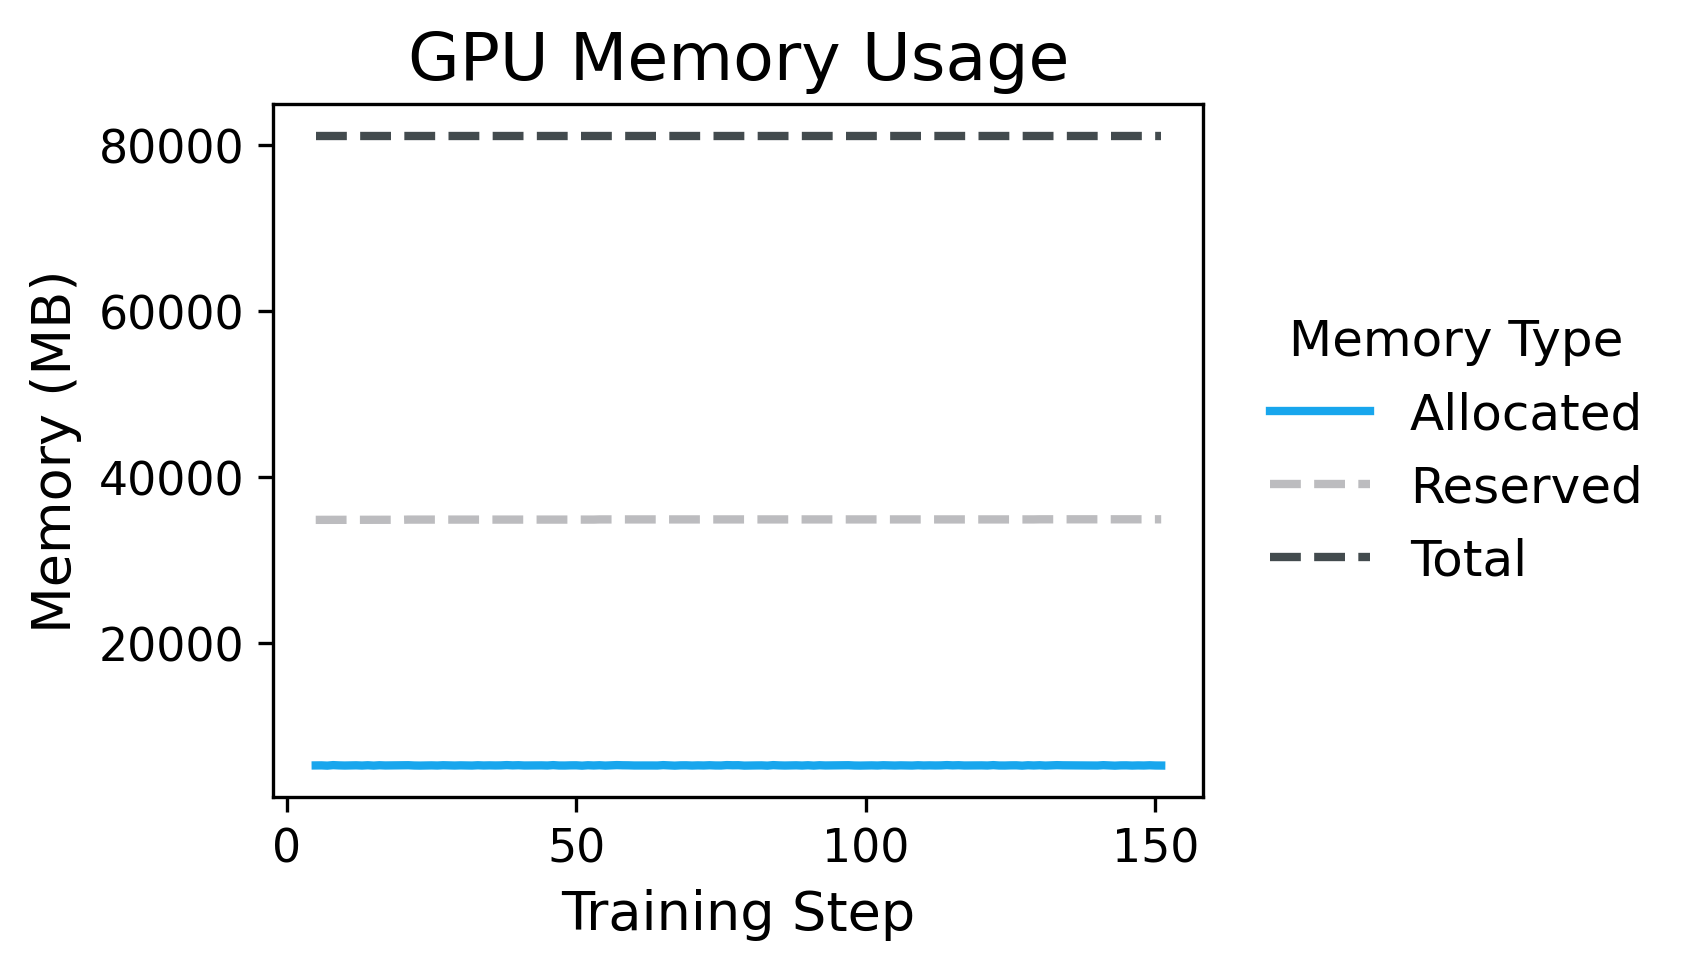

In [ ]:
gpu_memory_usage_fig = plot_gpu_memory(gpu_mem_df_all)
gpu_memory_usage_fig.show()

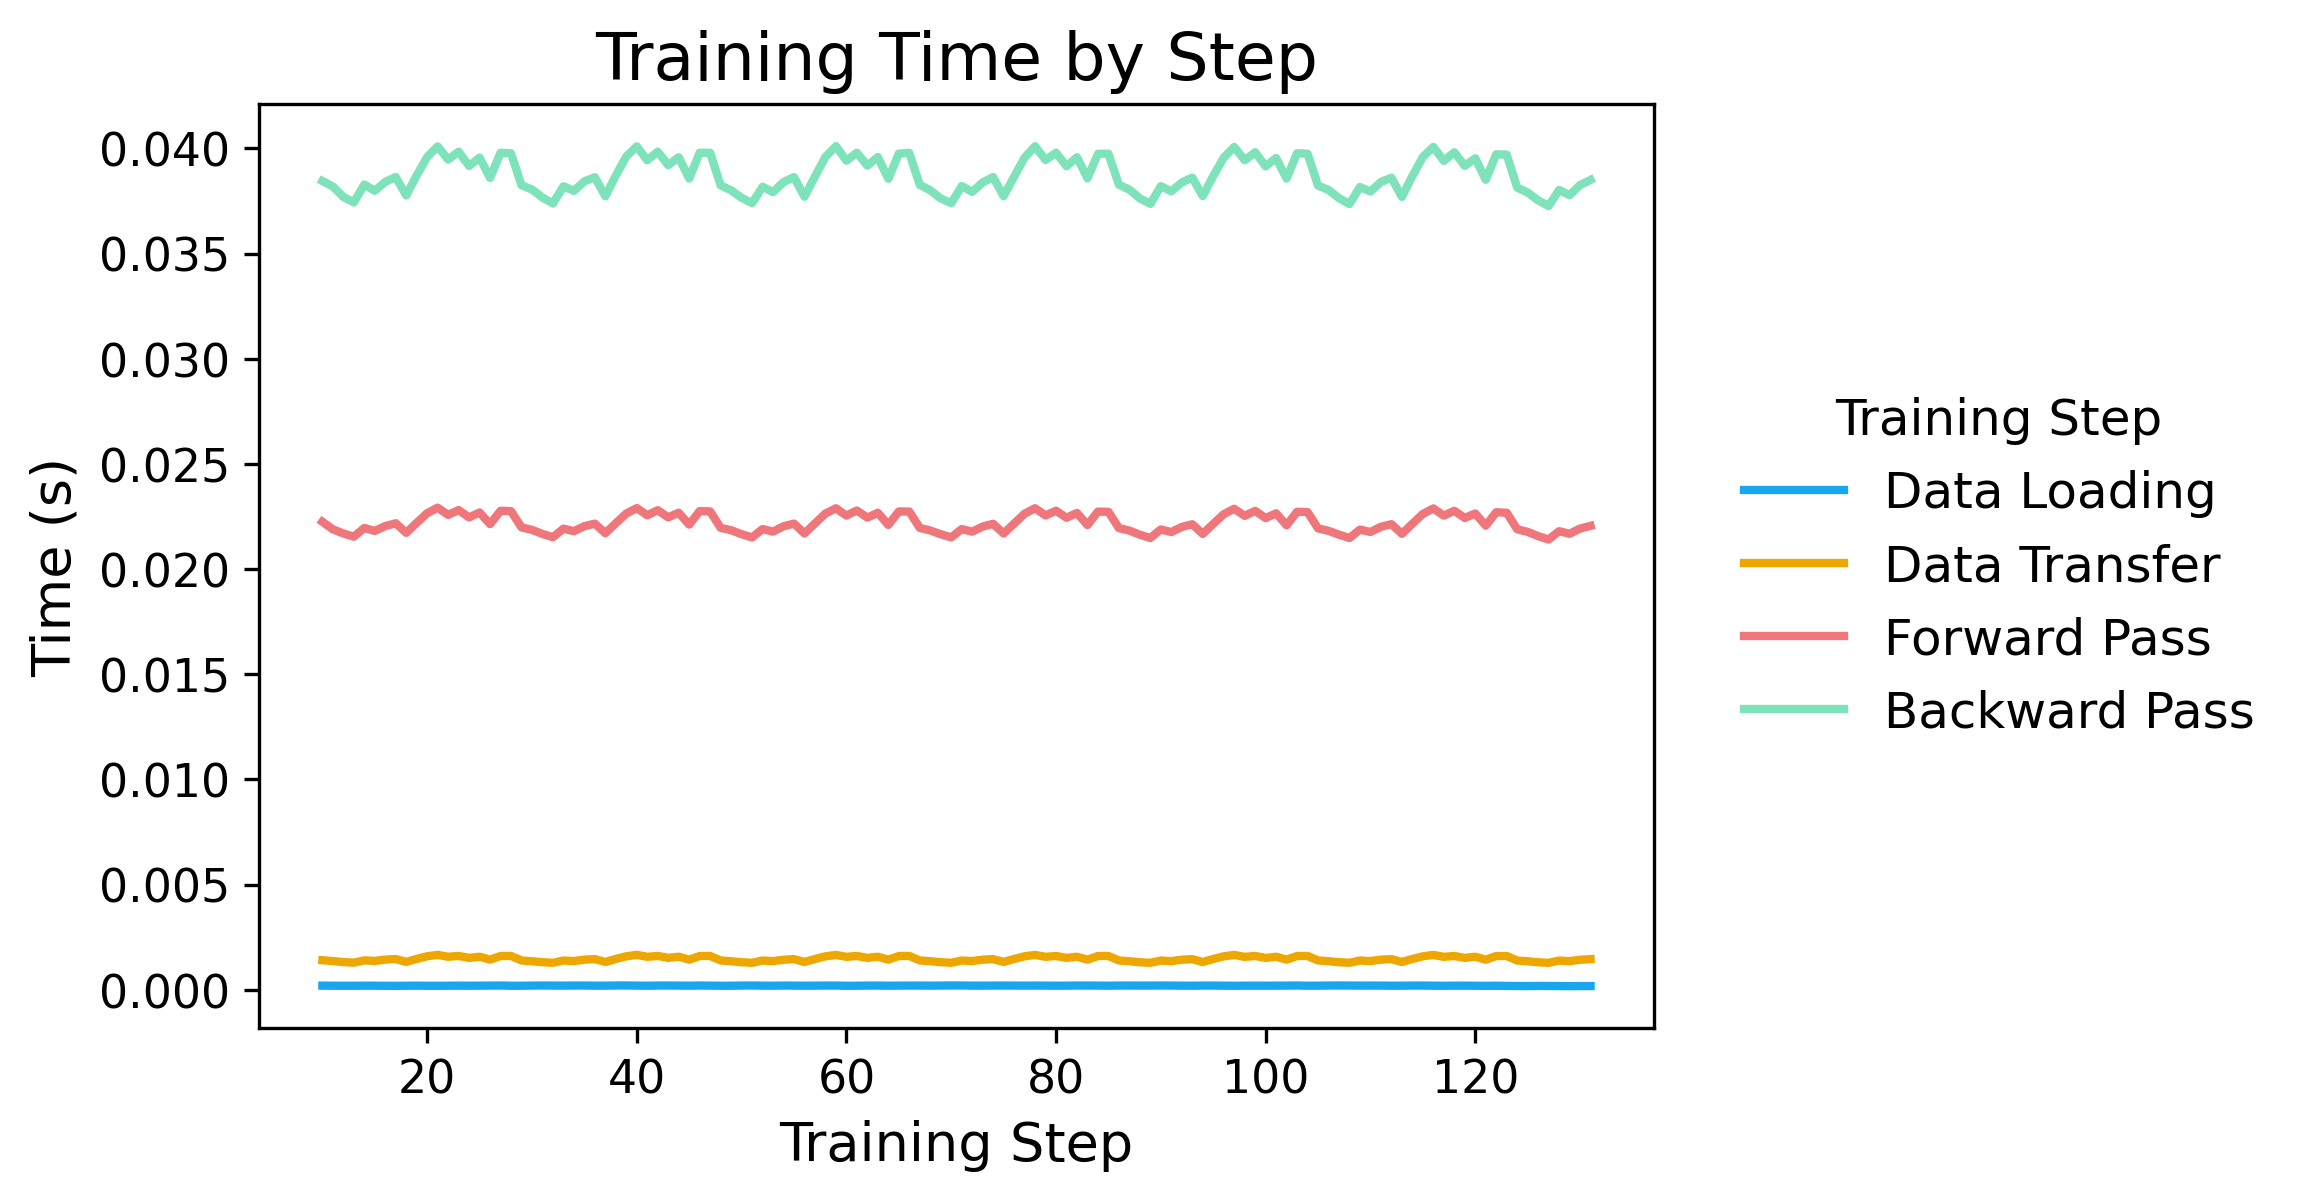

In [ ]:
training_time_by_step_fig = plot_training_time_by_step(batch_profile_df_all)
training_time_by_step_fig.show()

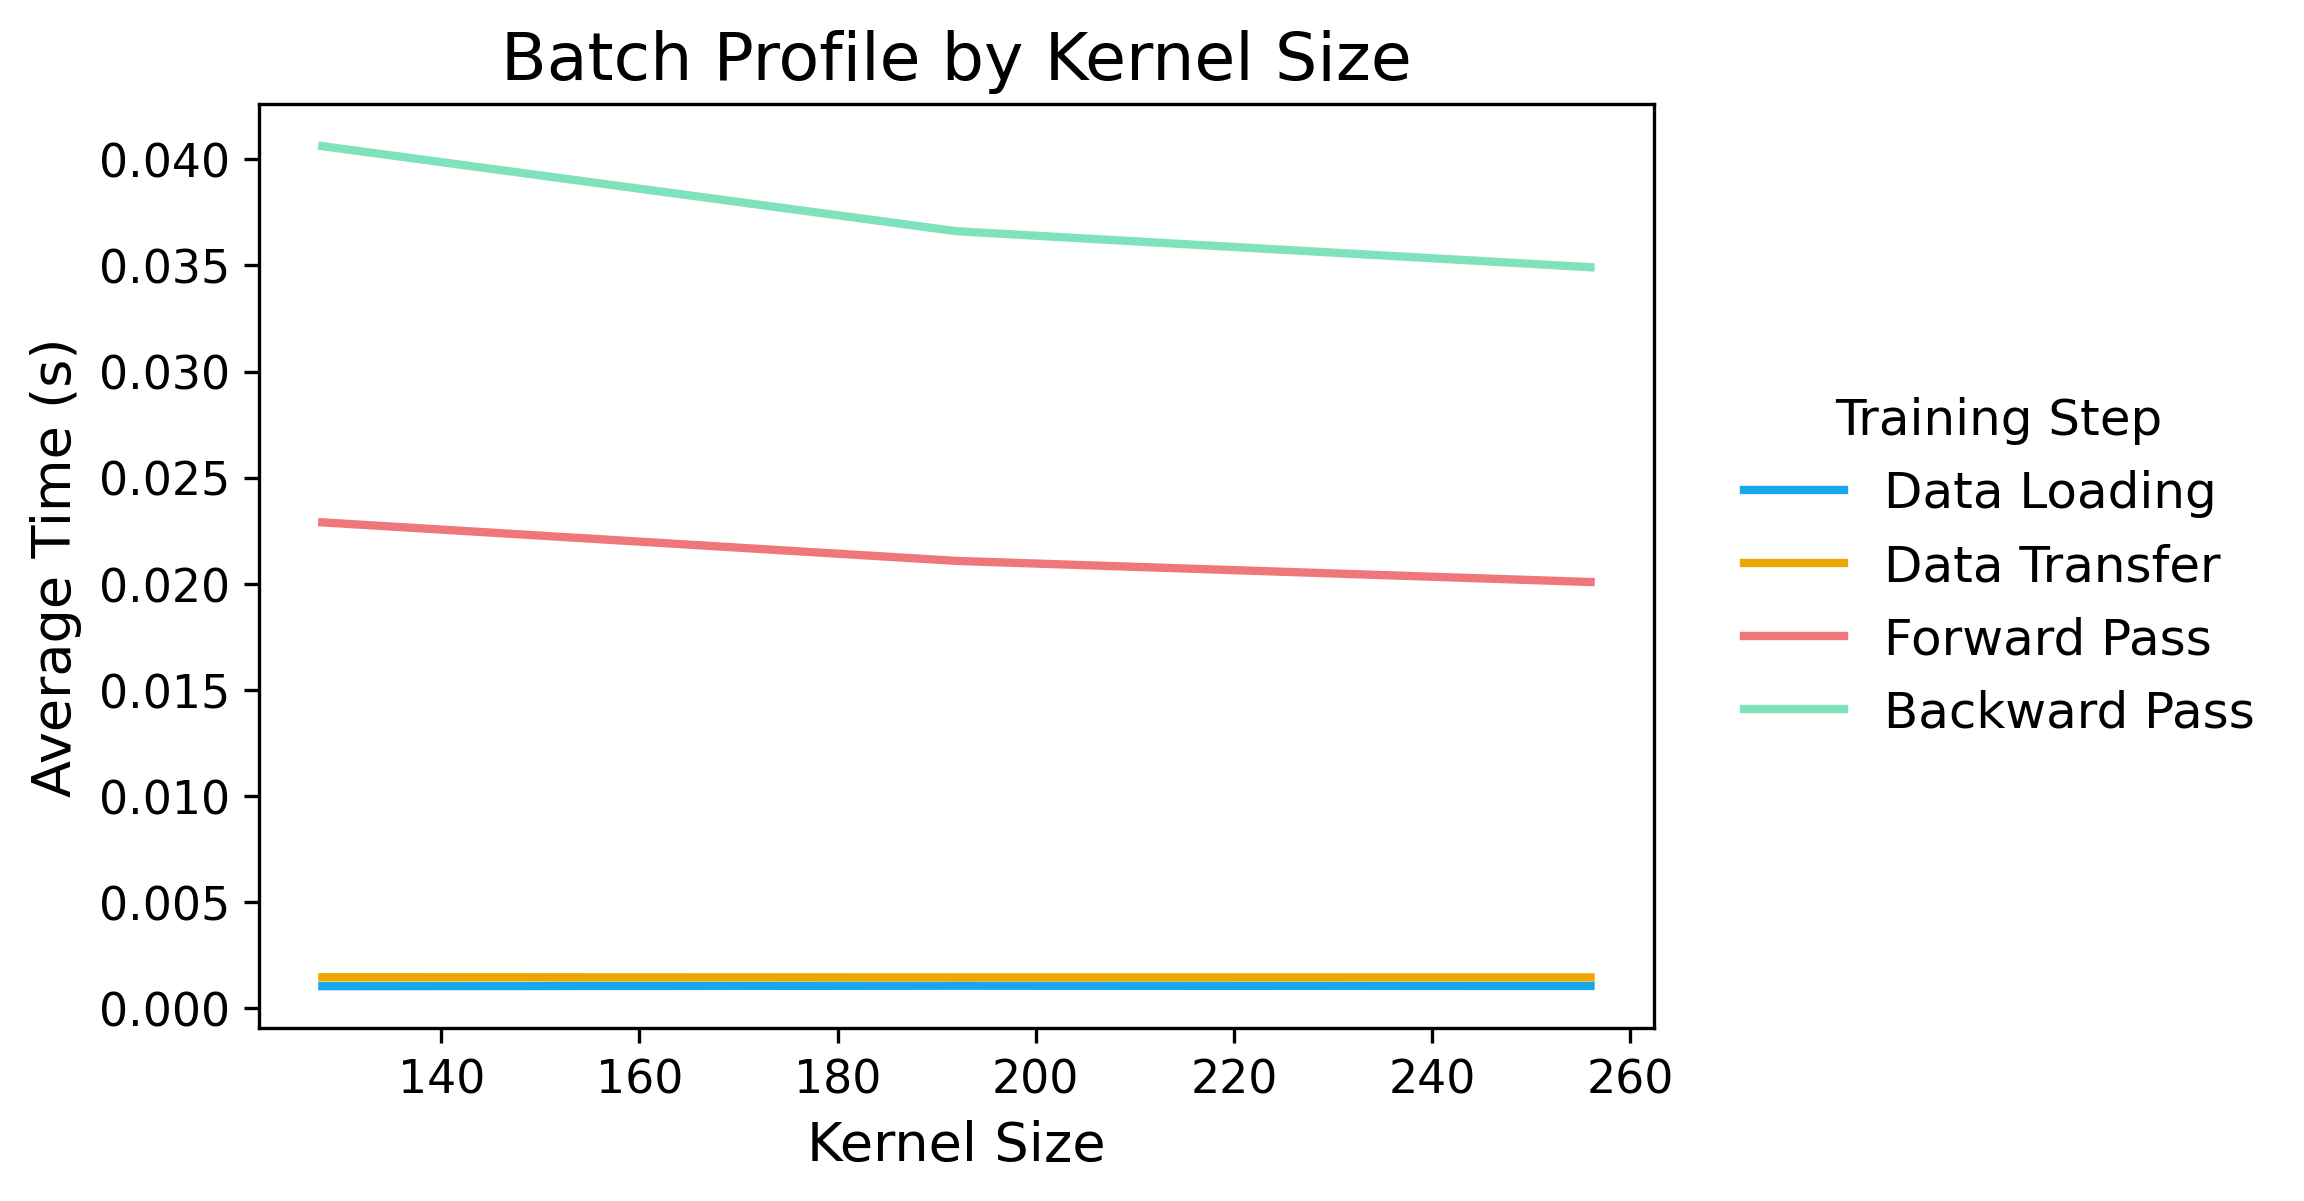

In [ ]:
train_time_by_kernel_size_fig= plot_train_step_time_by_kernel_size(batch_profile_df_all)
train_time_by_kernel_size_fig.show()

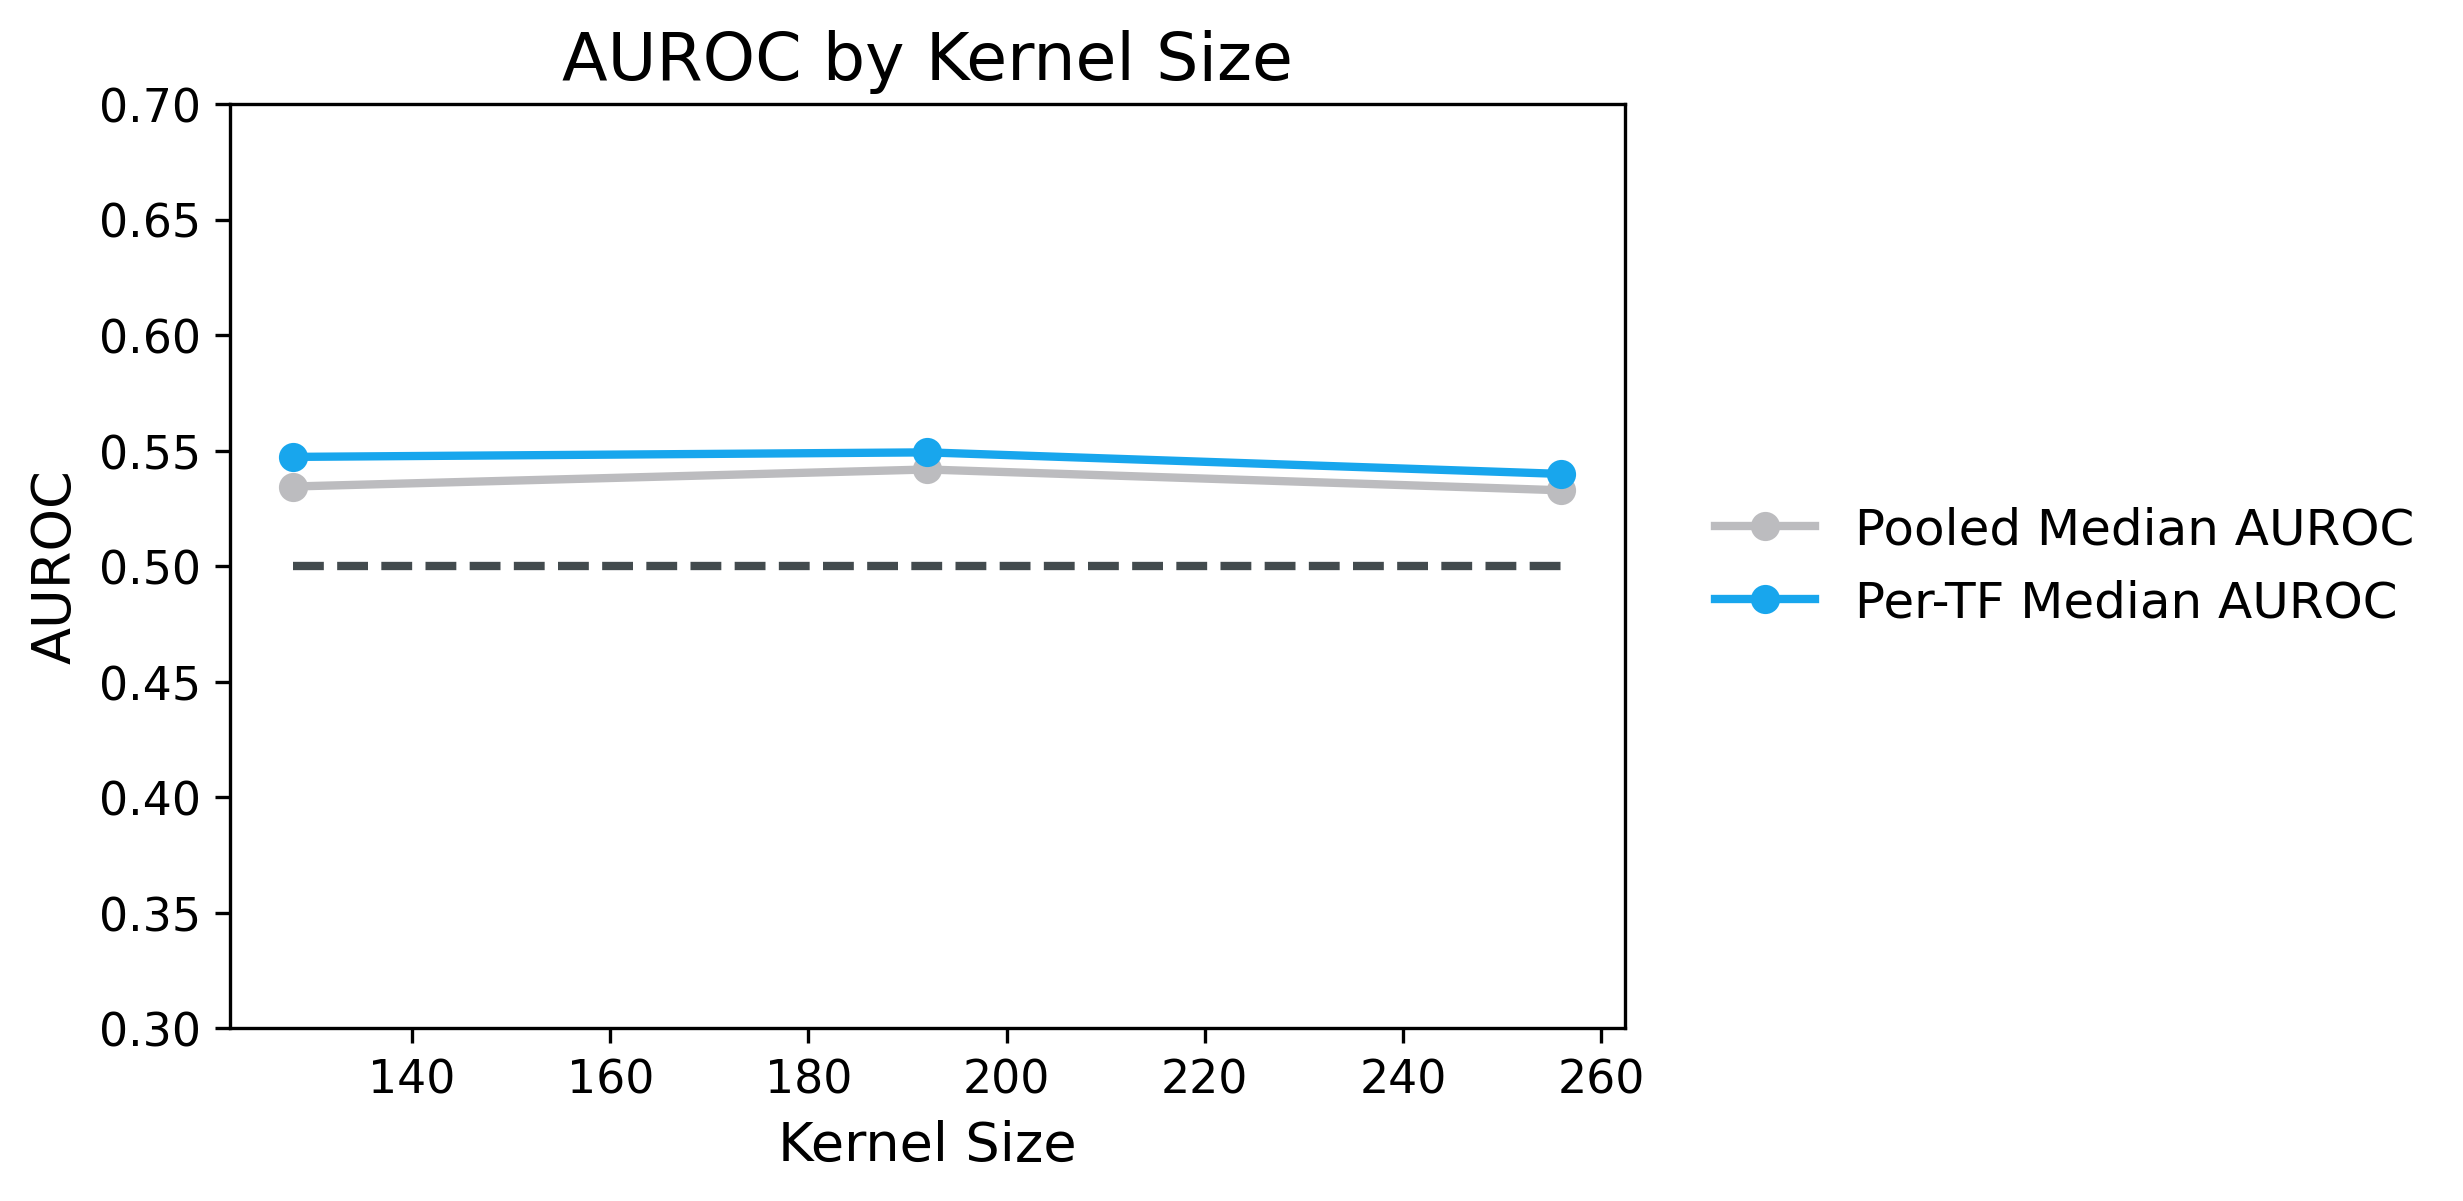

In [ ]:

    
auroc_by_kernel_size_fig = plot_auroc_by_kernel_size(auroc_df_all)
auroc_by_kernel_size_fig.show()


In [ ]:
gpu_mem_df_all.head()

,epoch,step,allocated_mb,reserved_mb,free_mb,total_memory_mb,allocated_pct_total,reserved_pct_total,free_pct_total,experiment_name,...,bias_scale,num_layers,num_heads,d_model,d_ff,kernel_size,dataloader_workers,max_cached,grad_attrib_batches,grad_attrib_tgs_per_batch
0,0,0,104.229004,21166.0,59446.875,81151.75,0.128437,26.082001,73.253966,mESC_muon_preprocessing_simplified_pooling,...,0.0,3,4,128,512,128,8,100,10,64
1,0,1,84.374512,21166.0,59446.875,81151.75,0.103971,26.082001,73.253966,mESC_muon_preprocessing_simplified_pooling,...,0.0,3,4,128,512,128,8,100,10,64
2,0,2,91.641113,21166.0,59446.875,81151.75,0.112926,26.082001,73.253966,mESC_muon_preprocessing_simplified_pooling,...,0.0,3,4,128,512,128,8,100,10,64
3,0,3,73.524414,21166.0,59446.875,81151.75,0.090601,26.082001,73.253966,mESC_muon_preprocessing_simplified_pooling,...,0.0,3,4,128,512,128,8,100,10,64
4,0,4,90.492188,21166.0,59446.875,81151.75,0.111510,26.082001,73.253966,mESC_muon_preprocessing_simplified_pooling,...,0.0,3,4,128,512,128,8,100,10,64


In [ ]:
running_batch_metrics = []

ground_truth = exp.load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_macrophage.csv")
ground_truth_df, gt_lookup = ground_truth
for b_idx, batch_df in tqdm(
    sorted(grad_batch_dfs.items()),
    total=len(grad_batch_dfs),
    ncols=100,
    desc="Evaluating batches"
):
    df = format_grn(batch_df)[["Source", "Target", "Score"]].copy()
    
    labeled_df = exp.create_ground_truth_comparison_df(df, gt_lookup, "ChIP-Atlas macrophage")

    y_all = labeled_df["_in_gt"].fillna(0).astype(int).to_numpy()
    s_all = labeled_df["Score"].to_numpy()
    
    pooled_auroc = quick_pooled_auroc(exp, labeled_df)
    per_tf_median_auroc = quick_per_tf_auroc(exp, labeled_df)

    running_batch_metrics.append({
        "batch_num": b_idx,
        "pooled_auroc": pooled_auroc,
        "per_tf_median_auroc": per_tf_median_auroc,

    })

auroc_by_num_batches = pd.DataFrame(running_batch_metrics).sort_values("batch_num")

Evaluating batches: 100%|███████████████████████████████████████████| 50/50 [03:15<00:00,  3.91s/it]


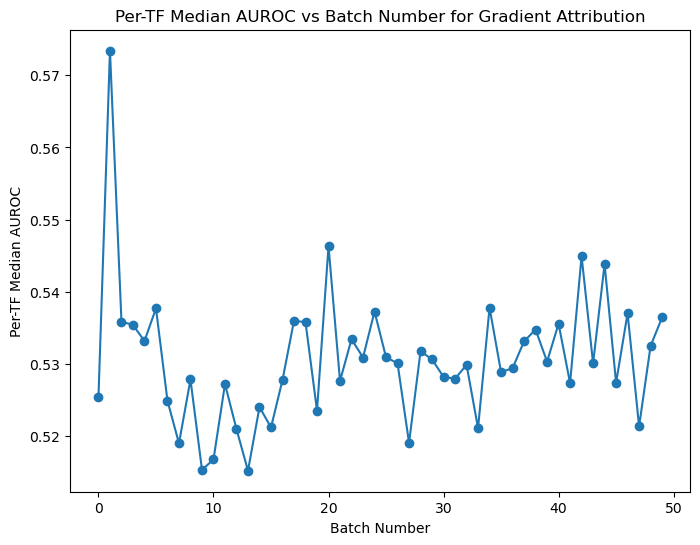

In [ ]:
auroc_by_batch_num = auroc_by_num_batches.groupby("batch_num")["per_tf_median_auroc"].mean().reset_index()
plt.figure(figsize=(8, 6))
plt.plot(auroc_by_batch_num["batch_num"], auroc_by_batch_num["per_tf_median_auroc"], marker="o")
plt.xlabel("Batch Number")
plt.ylabel("Per-TF Median AUROC")
plt.title("Per-TF Median AUROC vs Batch Number for Gradient Attribution")
plt.show()

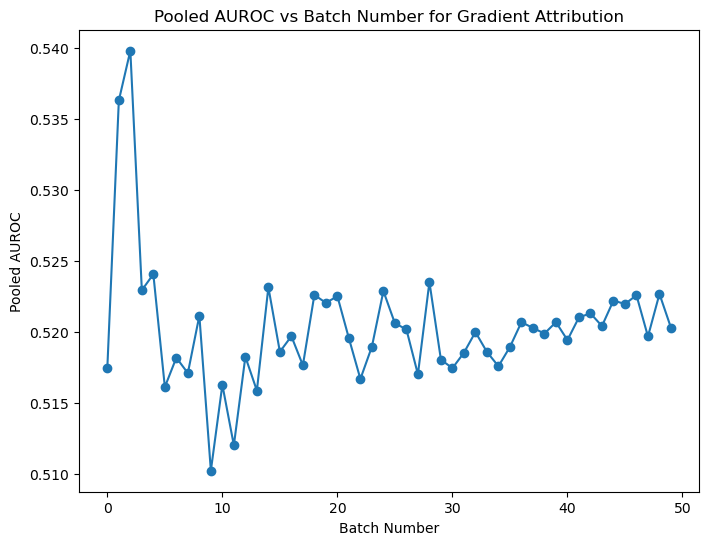

In [ ]:
auroc_by_batch_num = auroc_by_num_batches.groupby("batch_num")["pooled_auroc"].mean().reset_index()
plt.figure(figsize=(8, 6))
plt.plot(auroc_by_batch_num["batch_num"], auroc_by_batch_num["pooled_auroc"], marker="o")
plt.xlabel("Batch Number")
plt.ylabel("Pooled AUROC")
plt.title("Pooled AUROC vs Batch Number for Gradient Attribution")
plt.show()